In [ ]:
# -*- coding: utf-8 -*-
"""XU_LY_DONATEACRY_HOAN_CHINH.ipynb
XỬ LÝ DONATE-A-CRY - GIỮ NGUYÊN TÊN GỐC, KHÔNG LỌC TRÙNG ID
"""

import os
import subprocess
import librosa
import soundfile as sf
import numpy as np
from tqdm import tqdm
from collections import Counter
import shutil
import re

# ============================================
# KHAI BÁO ĐƯỜNG DẪN
# ============================================
DONATEACRY_PATH = r'C:\mangcambien\donateacry-corpus-master'
OUTPUT_PATH = r'C:\mangcambien\data_da_xu_ly\baby_cry'
FFMPEG_PATH = r'C:\ffmpeg\ffmpeg-8.0.1-full_build\bin\ffmpeg.exe'

# Tham số chuẩn
TARGET_SR = 22050
TARGET_DURATION = 5

# Mapping reason code
REASON_MAPPING = {
    'hu': 'hungry',
    'bu': 'burping',
    'bp': 'belly_pain',
    'dc': 'discomfort',
    'ti': 'tired',
    'lo': 'lonely',
    'ch': 'cold_hot',
    'sc': 'scared',
    'dk': 'unknown'
}

print("="*80)
print("📊 TIỀN XỬ LÝ DONATE-A-CRY - GIỮ NGUYÊN TÊN GỐC")
print("="*80)

# ============================================
# KIỂM TRA FFMPEG
# ============================================
def check_ffmpeg():
    if not os.path.exists(FFMPEG_PATH):
        print(f"❌ Không tìm thấy FFmpeg tại: {FFMPEG_PATH}")
        return False
    try:
        result = subprocess.run([FFMPEG_PATH, '-version'], capture_output=True, text=True)
        if result.returncode == 0:
            print(f"✅ FFmpeg OK")
            return True
    except:
        return False

if not check_ffmpeg():
    print("❌ FFmpeg không hoạt động. Thoát!")
    exit()

# ============================================
# TÌM TẤT CẢ FILE GỐC
# ============================================
print("\n🔍 ĐANG TÌM FILE GỐC...")

all_files = []
file_details = []

for root, dirs, files in os.walk(DONATEACRY_PATH):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext in ['.wav', '.caf', '.mp3', '.ogg', '.m4a', '.3gp']:
            full_path = os.path.join(root, file)
            
            # Lấy thông tin từ tên file
            basename = os.path.basename(file)
            name = os.path.splitext(basename)[0]
            parts = name.split('-')
            
            # Xác định reason code từ phần cuối của tên file
            if len(parts) >= 1:
                # Lấy phần cuối làm reason code
                last_part = parts[-1].lower()
                # Kiểm tra nếu phần cuối là một reason code hợp lệ
                if last_part in REASON_MAPPING:
                    reason_code = last_part
                    # Tên file gốc (loại bỏ reason code ở cuối nếu cần)
                    original_name = '-'.join(parts[:-1]) if len(parts) > 1 else name
                else:
                    # Nếu không phải reason code, thử kiểm tra phần trước đó
                    reason_code = 'unknown'
                    original_name = name
                    # Thử tìm reason code trong tên
                    for code in REASON_MAPPING.keys():
                        if code in parts:
                            reason_code = code
                            break
            else:
                reason_code = 'unknown'
                original_name = name
            
            file_details.append({
                'path': full_path,
                'name': file,
                'original_name': original_name,
                'ext': ext,
                'reason_code': reason_code,
                'valid': reason_code in REASON_MAPPING
            })

print(f"📁 Tổng số file tìm thấy: {len(file_details)}")

# ============================================
# THỐNG KÊ BAN ĐẦU
# ============================================
print("\n📊 THỐNG KÊ BAN ĐẦU:")

# Theo định dạng file
ext_stats = Counter(d['ext'] for d in file_details)
print("\n📁 Theo định dạng:")
for ext, count in ext_stats.most_common():
    print(f"   {ext:6}: {count:4d} file")

# Theo reason code
reason_stats = Counter(d['reason_code'] for d in file_details if d['valid'])
print("\n🎯 Theo reason code (chỉ file hợp lệ):")
total_valid = sum(reason_stats.values())
for code, count in reason_stats.most_common():
    reason_name = REASON_MAPPING.get(code, 'unknown')
    percent = count / total_valid * 100 if total_valid > 0 else 0
    print(f"   {code:2} ({reason_name:12}): {count:4d} file ({percent:5.2f}%)")

print(f"\n✅ File hợp lệ: {total_valid} file")
print(f"❌ File không hợp lệ: {len(file_details) - total_valid} file")

# ============================================
# CHỌN TẤT CẢ FILE HỢP LỆ (KHÔNG LỌC TRÙNG ID)
# ============================================
print("\n🎯 CHỌN TẤT CẢ FILE HỢP LỆ (KHÔNG XỬ LÝ TRÙNG LẶP)...")

selected_files = [d for d in file_details if d['valid']]

print(f"\n📊 KẾT QUẢ:")
print(f"   - Tổng số file hợp lệ: {len(selected_files)}")
print(f"   - Giữ nguyên tất cả file (không lọc trùng ID)")

# ============================================
# THỐNG KÊ PHÂN BỐ REASON CODE
# ============================================
final_reason_stats = Counter(d['reason_code'] for d in selected_files)
print("\n📊 PHÂN BỐ THEO REASON CODE:")
total_final = sum(final_reason_stats.values())
for code, count in final_reason_stats.most_common():
    reason_name = REASON_MAPPING.get(code, 'unknown')
    percent = count / total_final * 100 if total_final > 0 else 0
    print(f"   {code:2} ({reason_name:12}): {count:4d} file ({percent:5.2f}%)")

# ============================================
# XỬ LÝ FILE - GIỮ NGUYÊN TÊN GỐC
# ============================================
print("\n🔄 ĐANG XỬ LÝ FILE...")

# Xóa thư mục output cũ
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Thư mục tạm
temp_dir = os.path.join(OUTPUT_PATH, 'temp')
os.makedirs(temp_dir, exist_ok=True)

success = 0
failed = 0
error_files = []

for file_info in tqdm(selected_files, desc="Xử lý"):
    file_path = file_info['path']
    ext = file_info['ext']
    reason_code = file_info['reason_code']
    reason_name = REASON_MAPPING.get(reason_code, 'unknown')
    original_name = file_info['original_name']
    
    # Tạo tên file output: giữ nguyên tên gốc + reason
    # Làm sạch tên file để tránh ký tự đặc biệt
    clean_name = re.sub(r'[<>:"/\\|?*]', '_', original_name)
    if not clean_name:
        clean_name = f"unknown_{hash(file_path) % 10000:04d}"
    
    output_file = os.path.join(OUTPUT_PATH, f"{clean_name}_{reason_name}.wav")
    
    # Xử lý trùng tên file (nếu có)
    counter = 1
    original_output = output_file
    while os.path.exists(output_file):
        name_part = original_output.replace('.wav', '')
        output_file = f"{name_part}_{counter}.wav"
        counter += 1
    
    try:
        if ext == '.wav':
            # Xử lý trực tiếp file WAV
            y, sr = librosa.load(file_path, sr=None, mono=True)
            
            # Resample nếu cần
            if sr != TARGET_SR:
                y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
            
            # Cắt hoặc padding về 5 giây
            target_length = TARGET_DURATION * TARGET_SR
            if len(y) > target_length:
                y = y[:target_length]
            elif len(y) < target_length:
                y = np.pad(y, (0, target_length - len(y)), 'constant')
            
            # Chuẩn hóa biên độ về [-1, 1]
            if np.max(np.abs(y)) > 0:
                y = y / np.max(np.abs(y))
            
            # Lưu file
            sf.write(output_file, y, TARGET_SR, subtype='PCM_16')
            success += 1
            
        else:
            # File khác: dùng FFmpeg convert trước
            temp_file = os.path.join(temp_dir, f"temp_{hash(file_path)}.wav")
            
            # FFmpeg command
            cmd = [
                FFMPEG_PATH,
                '-i', file_path,
                '-ac', '1',           # mono
                '-ar', str(TARGET_SR), # sample rate
                '-y',                  # overwrite
                temp_file
            ]
            
            result = subprocess.run(cmd, capture_output=True, timeout=120)
            
            if result.returncode == 0:
                # Đọc file tạm và xử lý tiếp
                y, sr = librosa.load(temp_file, sr=None, mono=True)
                
                # Cắt/padding
                target_length = TARGET_DURATION * TARGET_SR
                if len(y) > target_length:
                    y = y[:target_length]
                elif len(y) < target_length:
                    y = np.pad(y, (0, target_length - len(y)), 'constant')
                
                # Chuẩn hóa biên độ
                if np.max(np.abs(y)) > 0:
                    y = y / np.max(np.abs(y))
                
                # Lưu file
                sf.write(output_file, y, TARGET_SR, subtype='PCM_16')
                success += 1
                
                # Xóa file tạm
                if os.path.exists(temp_file):
                    os.remove(temp_file)
            else:
                failed += 1
                error_files.append(file_info['name'])
                
    except Exception as e:
        print(f"\n❌ Lỗi {file_info['name']}: {e}")
        failed += 1
        error_files.append(file_info['name'])

# Dọn dẹp thư mục tạm
try:
    shutil.rmtree(temp_dir)
except:
    pass

# ============================================
# KẾT QUẢ CUỐI CÙNG
# ============================================
print("\n" + "="*80)
print("📊 KẾT QUẢ XỬ LÝ DONATE-A-CRY")
print("="*80)

print(f"""
✅ THÀNH CÔNG: {success} file
❌ THẤT BẠI: {failed} file
📁 OUTPUT: {OUTPUT_PATH}
""")

# Liệt kê file lỗi nếu có
if error_files:
    print("\n📋 DANH SÁCH FILE LỖI:")
    for f in error_files[:10]:
        print(f"   - {f}")

# Kiểm tra file đã xử lý
final_files = sorted([f for f in os.listdir(OUTPUT_PATH) if f.endswith('.wav')])

print(f"\n📁 TỔNG SỐ FILE OUTPUT: {len(final_files)}")

if len(final_files) == success:
    print(f"✅ KHỚP: {len(final_files)}/{success}")
else:
    print(f"⚠️ KHÔNG KHỚP: {len(final_files)}/{success}")

# Kiểm tra chất lượng 5 file đầu
print("\n🔍 KIỂM TRA CHẤT LƯỢNG 5 FILE ĐẦU:")
for f in final_files[:5]:
    file_path = os.path.join(OUTPUT_PATH, f)
    y, sr = librosa.load(file_path, sr=None)
    duration = len(y) / sr
    
    print(f"\n   📄 {f}")
    print(f"      - Sample rate: {sr} Hz (target: {TARGET_SR})")
    print(f"      - Duration: {duration:.2f}s (target: {TARGET_DURATION}s)")
    print(f"      - Amplitude: [{y.min():.3f}, {y.max():.3f}]")

# Lưu log
import pandas as pd
log_data = []
for f in final_files:
    file_path = os.path.join(OUTPUT_PATH, f)
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = len(y) / sr
        log_data.append({
            'filename': f,
            'sample_rate': sr,
            'duration': duration,
            'amplitude_min': y.min(),
            'amplitude_max': y.max(),
            'status': 'OK'
        })
    except:
        log_data.append({
            'filename': f,
            'sample_rate': 0,
            'duration': 0,
            'amplitude_min': 0,
            'amplitude_max': 0,
            'status': 'ERROR'
        })

log_df = pd.DataFrame(log_data)
log_df.to_csv(os.path.join(OUTPUT_PATH, '..', 'donateacry_processed_log.csv'), index=False)
print(f"\n💾 Đã lưu log tại: {os.path.join(OUTPUT_PATH, '..', 'donateacry_processed_log.csv')}")

print("\n" + "="*80)
print("✅ HOÀN TẤT XỬ LÝ DONATE-A-CRY!")
print("="*80)

In [ ]:
# -*- coding: utf-8 -*-
"""XU_LY_ESC50_HOUSEHOLD_NOISE.ipynb
XỬ LÝ ESC-50 - LẤY CÁC LỚP HOUSEHOLD NOISE VÀ THÊM GROUP_ID VÀO TÊN FILE
"""

import os
import librosa
import soundfile as sf
import numpy as np
import pandas as pd
from tqdm import tqdm
import shutil
import re

# ============================================
# ĐƯỜNG DẪN
# ============================================
ESC50_PATH = r'C:\mangcambien\ESC-50-master'
OUTPUT_PATH = r'C:\mangcambien\data_da_xu_ly'

# Tạo folder riêng cho household noise
HOUSEHOLD_NOISE_PATH = os.path.join(OUTPUT_PATH, 'household_noise')

# Xóa thư mục cũ nếu tồn tại
if os.path.exists(HOUSEHOLD_NOISE_PATH):
    shutil.rmtree(HOUSEHOLD_NOISE_PATH)
    print("🗑️ Đã xóa thư mục cũ")
os.makedirs(HOUSEHOLD_NOISE_PATH, exist_ok=True)

# Tham số chuẩn
TARGET_SR = 22050
TARGET_DURATION = 5

print("="*70)
print("📊 XỬ LÝ ESC-50 - HOUSEHOLD NOISE")
print("="*70)
print(f"\n🎯 THAM SỐ CHUẨN HÓA:")
print(f"   - Sample rate: {TARGET_SR} Hz")
print(f"   - Độ dài: {TARGET_DURATION} giây")
print(f"   - Kênh: Mono")
print(f"📁 Output: {HOUSEHOLD_NOISE_PATH}")

# ============================================
# ĐỌC FILE META ESC-50
# ============================================
meta_path = os.path.join(ESC50_PATH, 'meta', 'esc50.csv')
df_esc = pd.read_csv(meta_path)

print(f"\n📁 Tổng số file ESC-50 gốc: {len(df_esc)}")

# LOẠI BỎ CRYING_BABY
df_esc_filtered = df_esc[df_esc['category'] != 'crying_baby'].copy()
print(f"👶 Đã loại bỏ crying_baby: {len(df_esc) - len(df_esc_filtered)} file")

# ============================================
# ĐỊNH NGHĨA CÁC LỚP HOUSEHOLD NOISE (TÊN CHÍNH XÁC TRONG ESC-50)
# ============================================
household_classes = [
    # Interior/domestic sounds
    'washing_machine',
    'vacuum_cleaner', 
    'clock_tick',
    'door_wood_knock',      # door_knock trong ESC-50 là 'door_wood_knock'?
    'keyboard_typing',
    'can_opening',
    
    # Human non-speech sounds  
    'coughing',
    'laughing',
    'snoring',
    'brushing_teeth',
    'sneezing',
    
    # Animal sounds
    'cat',
]

# Lọc dữ liệu
df_household = df_esc_filtered[df_esc_filtered['category'].isin(household_classes)].copy()

print(f"\n🏠 CÁC LỚP HOUSEHOLD NOISE ({len(household_classes)} lớp):")
total_files = 0
for cls in household_classes:
    count = len(df_household[df_household['category'] == cls])
    total_files += count
    print(f"   - {cls:25s}: {count} file")

print(f"\n📊 TỔNG SỐ FILE HOUSEHOLD NOISE: {total_files}")

# ============================================
# HÀM CHUẨN HÓA AUDIO
# ============================================
def normalize_audio(input_file, output_file):
    try:
        y, sr = librosa.load(input_file, sr=None, mono=True)
        
        if sr != TARGET_SR:
            y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
        
        target_length = TARGET_DURATION * TARGET_SR
        if len(y) > target_length:
            y = y[:target_length]
        elif len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), 'constant')
        
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))
        
        sf.write(output_file, y, TARGET_SR)
        return True, None
    except Exception as e:
        return False, str(e)

# ============================================
# XỬ LÝ TỪNG FILE - THÊM GROUP_ID VÀO TÊN
# ============================================
print("\n🔄 ĐANG XỬ LÝ FILE HOUSEHOLD NOISE...")
print("-" * 50)

audio_folder = os.path.join(ESC50_PATH, 'audio')
success = 0
failed = 0
group_stats = {str(i): 0 for i in range(1, 6)}

for idx, row in tqdm(df_household.iterrows(), total=len(df_household), desc="Xử lý"):
    file_path = os.path.join(audio_folder, row['filename'])
    original_filename = row['filename']
    
    # Lấy số đầu tiên làm group_id (fold của ESC-50: 1-5)
    group_id = original_filename[0] if original_filename[0].isdigit() else "0"
    
    # Tạo tên file mới: [group_id]_[original_name].wav
    new_filename = f"{group_id}_{original_filename}"
    output_file = os.path.join(HOUSEHOLD_NOISE_PATH, new_filename)
    
    success_flag, error_msg = normalize_audio(file_path, output_file)
    
    if success_flag:
        success += 1
        if group_id in group_stats:
            group_stats[group_id] += 1
    else:
        failed += 1
        print(f"\n❌ Lỗi {original_filename}: {error_msg}")

# ============================================
# THỐNG KÊ KẾT QUẢ
# ============================================
print("\n" + "="*70)
print("📊 THỐNG KÊ KẾT QUẢ")
print("="*70)

print(f"\n📊 Phân bố file theo group_id (số đầu tên file):")
for gid in sorted(group_stats.keys()):
    print(f"   - group_id = {gid}: {group_stats[gid]} file")
print(f"\n📊 Tổng số file đã xử lý: {success}")

print("\n🔍 10 FILE ĐẦU TIÊN:")
wav_files = sorted([f for f in os.listdir(HOUSEHOLD_NOISE_PATH) if f.endswith('.wav')])
for f in wav_files[:10]:
    print(f"   📄 {f}")

print("\n" + "="*70)
print("📋 TỔNG KẾT")
print("="*70)

print(f"""
✅ KẾT QUẢ:
   - Thành công: {success} file
   - Thất bại: {failed} file

📁 OUTPUT:
   - Đường dẫn: {HOUSEHOLD_NOISE_PATH}
   - Cấu trúc tên: [group_id]_[original_name].wav
   - group_id = số đầu tiên (1,2,3,4,5)

🎯 VÍ DỤ TÊN FILE:
   - 1_1-100032-A-0.wav
   - 2_2-100038-A-14.wav
   - 3_3-100032-A-0.wav

📤 UPLOAD LÊN EDGE IMPULSE:
   - Upload toàn bộ file trong thư mục này
   - Edge Impulse sẽ tự động lấy group_id từ tên file
""")

print("✅ HOÀN TẤT!")
print("="*70)

📊 VẼ BIỂU ĐỒ SO SÁNH BABY CRY VS HOUSEHOLD NOISE
📁 Baby Cry path: C:\mangcambien\data_da_xu_ly\baby_cry
📁 Noise path: C:\mangcambien\data_da_xu_ly\household_noise

📊 TỔNG SỐ FILE:
   - Baby Cry: 1583 file
   - Household Noise: 480 file

📈 Đang vẽ dạng sóng (waveform)...


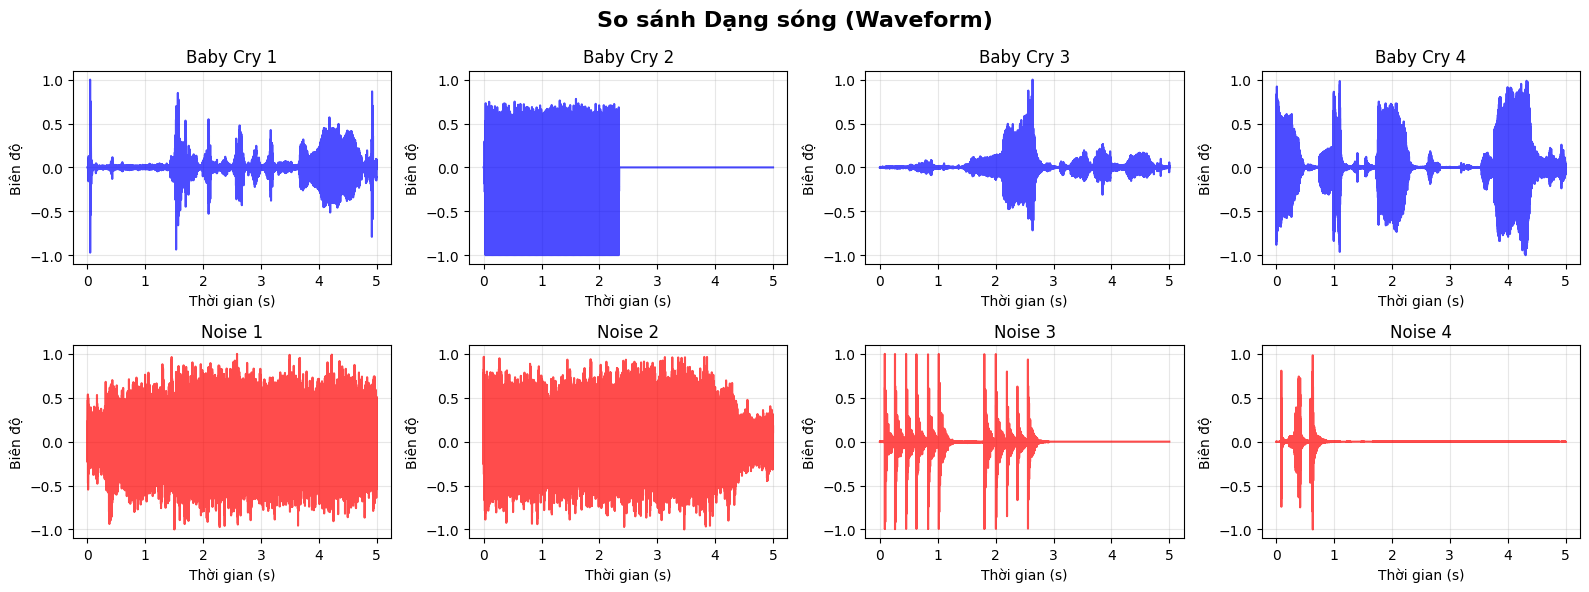

📈 Đang vẽ Mel-spectrogram...


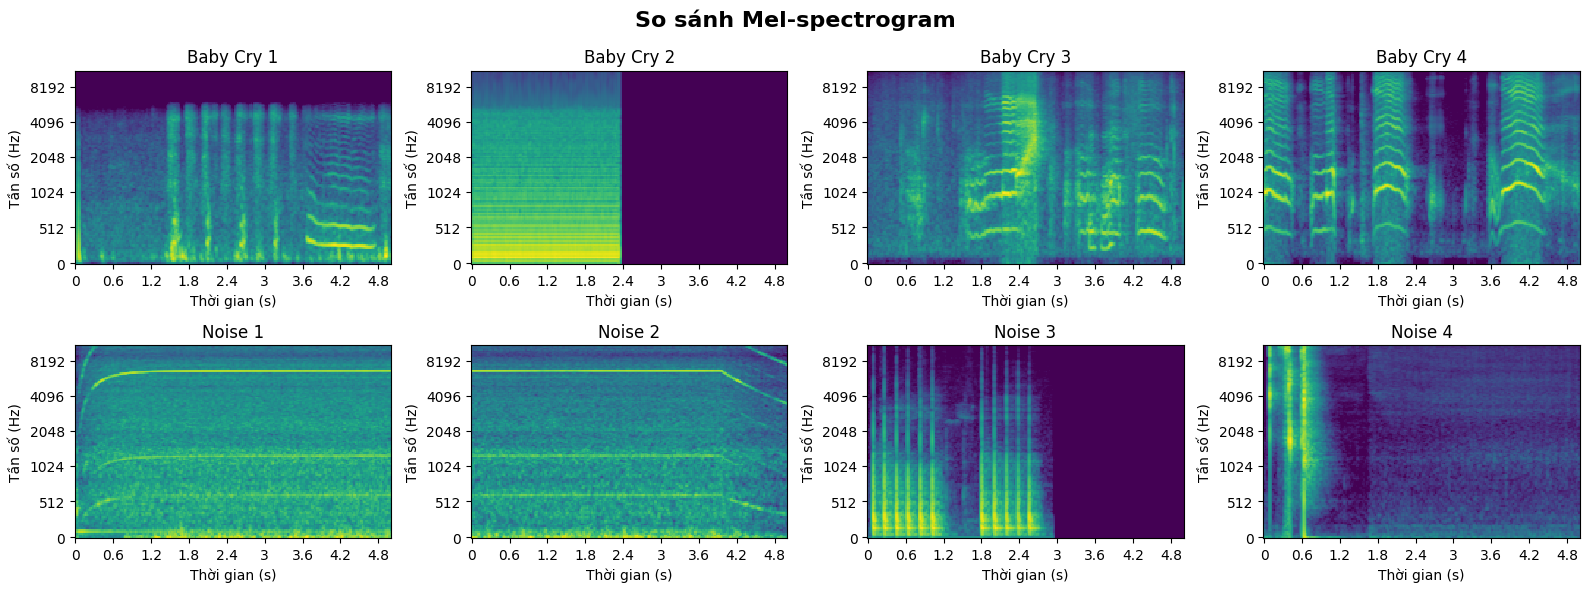

📊 Đang tính ZCR và RMS cho tất cả file...
   - Baby Cry...


100%|█████████████████████████████████████████████████████████████████████████████| 1583/1583 [00:14<00:00, 110.93it/s]


   - Household Noise...


100%|███████████████████████████████████████████████████████████████████████████████| 480/480 [00:03<00:00, 130.02it/s]



📈 Đang vẽ histogram ZCR và RMS...


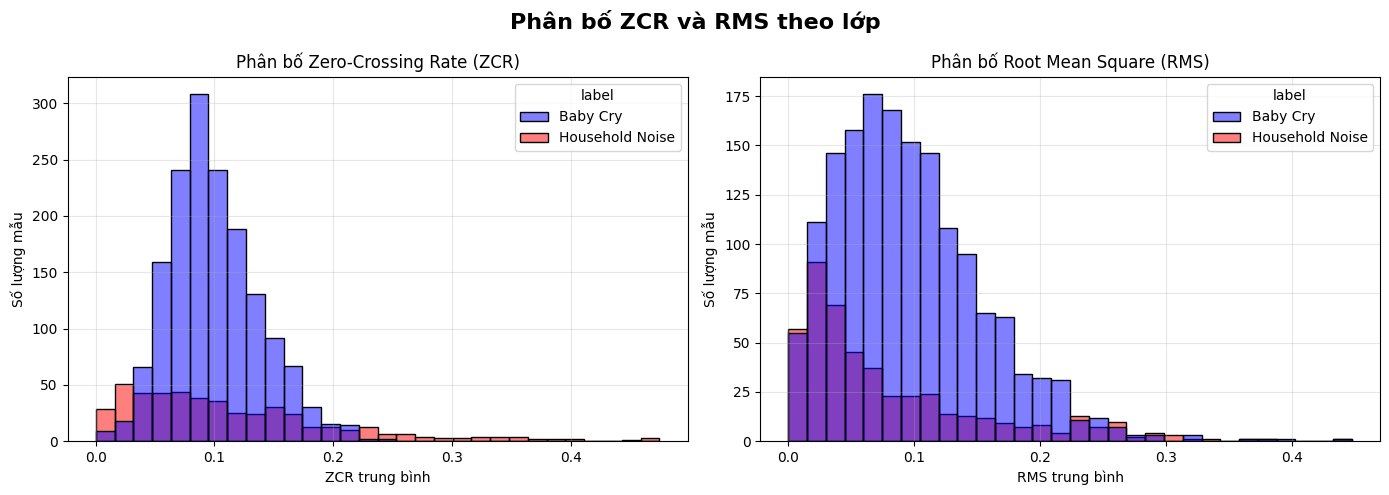


📈 Đang vẽ boxplot ZCR và RMS...


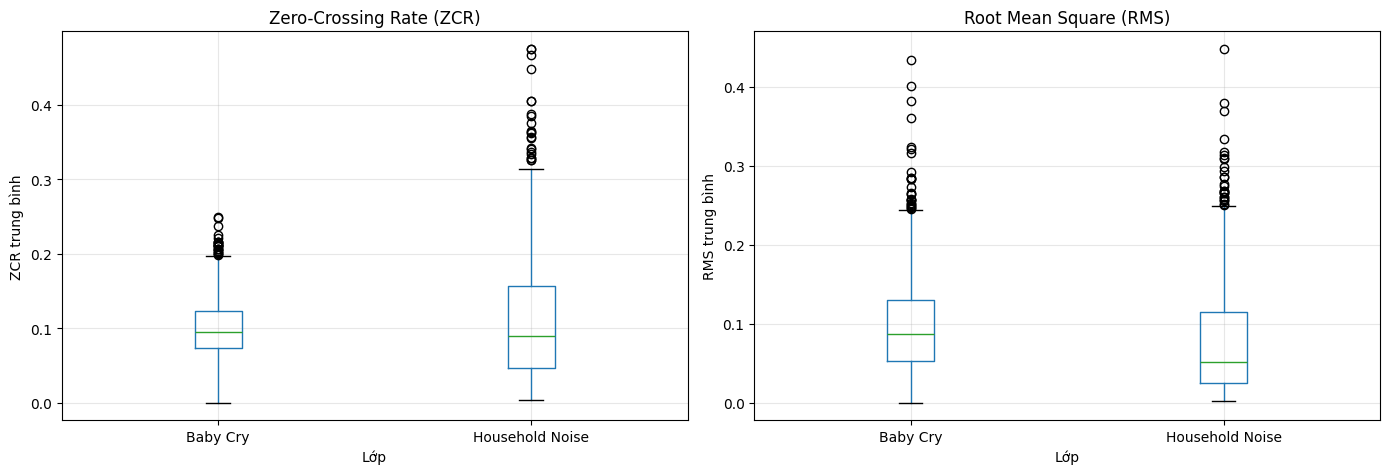


📈 Đang vẽ MFCC heatmap...


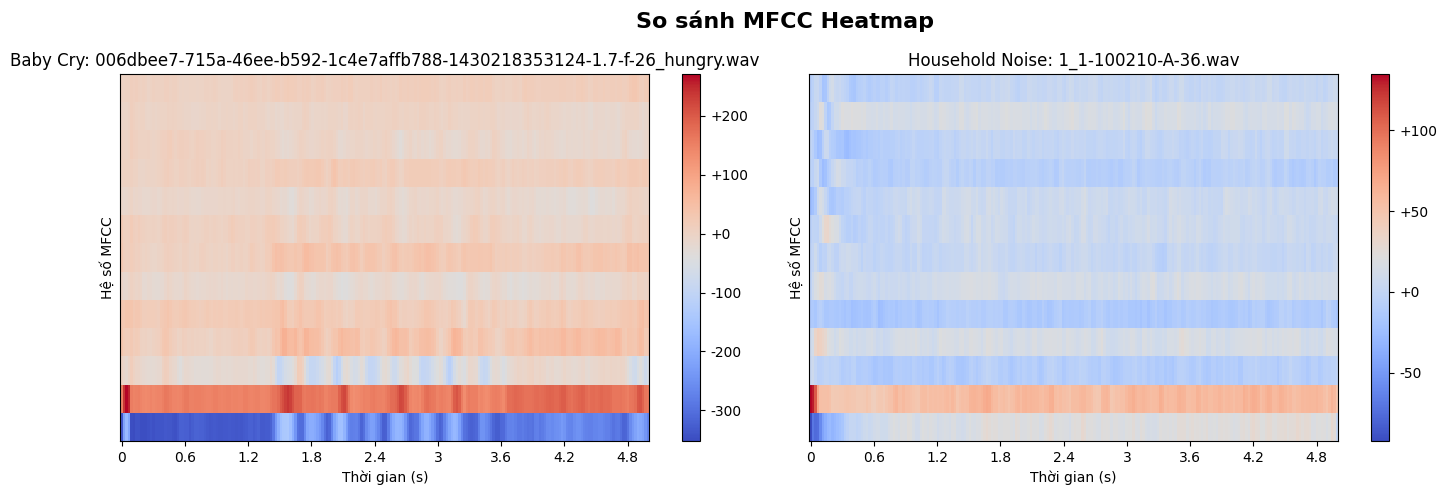


📈 Đang vẽ scatter plot ZCR vs RMS...


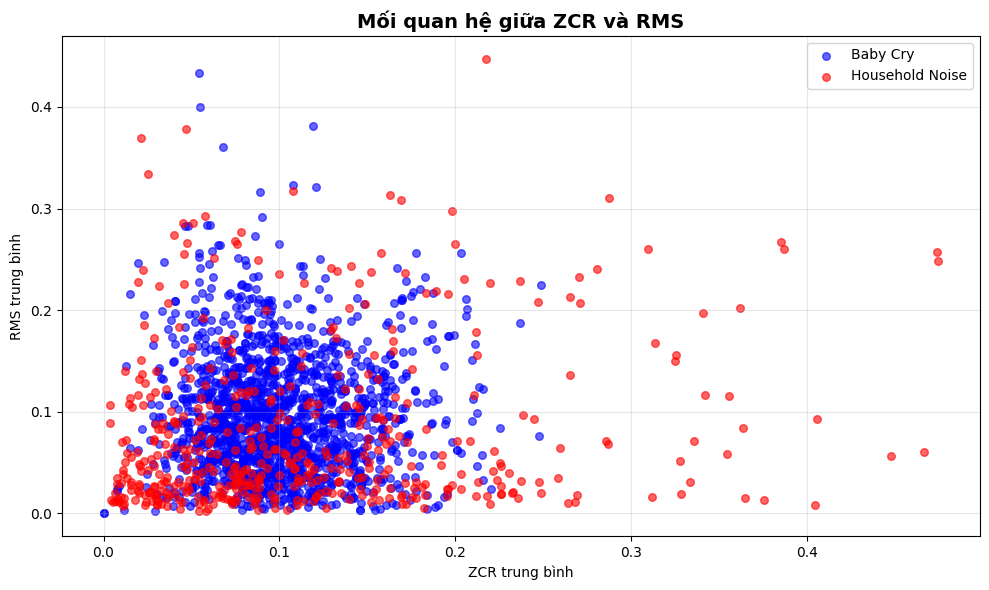


🔧 ĐANG TRÍCH XUẤT ĐẶC TRƯNG (FEATURE ENGINEERING)

📊 Đang trích xuất đặc trưng cho Baby Cry...


Baby Cry: 100%|████████████████████████████████████████████████████████████████████| 1583/1583 [01:07<00:00, 23.46it/s]



📊 Đang trích xuất đặc trưng cho Household Noise...


Noise: 100%|█████████████████████████████████████████████████████████████████████████| 480/480 [00:20<00:00, 23.45it/s]



🎲 GÁN FOLD CHO BABY CRY THEO UUID
📊 Số UUID duy nhất: 411
📊 Số UUID hợp lệ: 411
✅ Đã gán fold cho 1583 file baby cry theo UUID

📊 THỐNG KÊ DỮ LIỆU

📊 Tổng số file: 2063
   - Noise: 480 file
   - Baby Cry: 1583 file

📊 Phân bố fold của noise (từ số đầu tên file):
   Fold 1: 96 file
   Fold 2: 96 file
   Fold 3: 96 file
   Fold 4: 96 file
   Fold 5: 96 file

📊 Phân bố fold của baby cry (theo UUID):
   Fold 1: 403 file, 90 UUID
   Fold 2: 289 file, 74 UUID
   Fold 3: 238 file, 77 UUID
   Fold 4: 361 file, 96 UUID
   Fold 5: 292 file, 74 UUID

📊 Tổng phân bố fold:
   Fold 1: 499 file
   Fold 2: 385 file
   Fold 3: 334 file
   Fold 4: 457 file
   Fold 5: 388 file

🔍 KIỂM TRA DATA LEAKAGE
✅ Baby cry: Cùng UUID cùng fold
✅ Noise: Cùng số đầu cùng fold

💾 LƯU DỮ LIỆU
✅ Đã lưu file: audio_features_dataset_with_fold.csv

📋 TỔNG KẾT

✅ ĐÃ HOÀN THÀNH:

1. VẼ CÁC BIỂU ĐỒ (6 hình):
   - 01_waveform_comparison.png
   - 02_melspectrogram_comparison.png
   - 03_zcr_rms_histogram.png
   - 04_zcr_rms_bo

In [1]:
# -*- coding: utf-8 -*-
"""VE_DO_THI_VA_TRICH_XUAT_DAC_TRUNG.ipynb
VẼ BIỂU ĐỒ SO SÁNH VÀ TRÍCH XUẤT ĐẶC TRƯNG
"""

import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
import warnings
warnings.filterwarnings('ignore')

# ============================================
# KHAI BÁO ĐƯỜNG DẪN
# ============================================
BASE_PATH = r'C:\mangcambien\data_da_xu_ly'
BABY_CRY_PATH = os.path.join(BASE_PATH, 'baby_cry')
NOISE_PATH = os.path.join(BASE_PATH, 'household_noise')

print("="*70)
print("📊 VẼ BIỂU ĐỒ SO SÁNH BABY CRY VS HOUSEHOLD NOISE")
print("="*70)
print(f"📁 Baby Cry path: {BABY_CRY_PATH}")
print(f"📁 Noise path: {NOISE_PATH}")

# Kiểm tra đường dẫn
if not os.path.exists(BABY_CRY_PATH) or not os.path.exists(NOISE_PATH):
    print("❌ Lỗi: Không tìm thấy thư mục dữ liệu!")
    exit()

# ============================================
# LẤY DANH SÁCH FILE
# ============================================
baby_files = [f for f in os.listdir(BABY_CRY_PATH) if f.endswith('.wav')]
noise_files = [f for f in os.listdir(NOISE_PATH) if f.endswith('.wav')]

baby_paths = [os.path.join(BABY_CRY_PATH, f) for f in baby_files]
noise_paths = [os.path.join(NOISE_PATH, f) for f in noise_files]

print(f"\n📊 TỔNG SỐ FILE:")
print(f"   - Baby Cry: {len(baby_files)} file")
print(f"   - Household Noise: {len(noise_files)} file")

# Lấy mẫu để vẽ
n_samples = min(4, len(baby_files), len(noise_files))
baby_samples = baby_paths[:n_samples]
noise_samples = noise_paths[:n_samples]

# ============================================
# 1. VẼ DẠNG SÓNG (WAVEFORM)
# ============================================
print("\n📈 Đang vẽ dạng sóng (waveform)...")

fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 6))
fig.suptitle('So sánh Dạng sóng (Waveform)', fontsize=16, fontweight='bold')

for i, file_path in enumerate(baby_samples):
    y, sr = librosa.load(file_path, sr=22050)
    time = np.linspace(0, len(y)/sr, len(y))
    axes[0, i].plot(time, y, color='blue', alpha=0.7)
    axes[0, i].set_title(f'Baby Cry {i+1}')
    axes[0, i].set_xlabel('Thời gian (s)')
    axes[0, i].set_ylabel('Biên độ')
    axes[0, i].set_ylim([-1.1, 1.1])
    axes[0, i].grid(True, alpha=0.3)

for i, file_path in enumerate(noise_samples):
    y, sr = librosa.load(file_path, sr=22050)
    time = np.linspace(0, len(y)/sr, len(y))
    axes[1, i].plot(time, y, color='red', alpha=0.7)
    axes[1, i].set_title(f'Noise {i+1}')
    axes[1, i].set_xlabel('Thời gian (s)')
    axes[1, i].set_ylabel('Biên độ')
    axes[1, i].set_ylim([-1.1, 1.1])
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_waveform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 2. VẼ MEL-SPECTROGRAM
# ============================================
print("📈 Đang vẽ Mel-spectrogram...")

fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 6))
fig.suptitle('So sánh Mel-spectrogram', fontsize=16, fontweight='bold')

for i, file_path in enumerate(baby_samples):
    y, sr = librosa.load(file_path, sr=22050)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    log_mel = librosa.power_to_db(mel_spec)
    img = librosa.display.specshow(log_mel, sr=sr, x_axis='time', y_axis='mel', 
                                   ax=axes[0, i], cmap='viridis')
    axes[0, i].set_title(f'Baby Cry {i+1}')
    axes[0, i].set_xlabel('Thời gian (s)')
    axes[0, i].set_ylabel('Tần số (Hz)')

for i, file_path in enumerate(noise_samples):
    y, sr = librosa.load(file_path, sr=22050)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    log_mel = librosa.power_to_db(mel_spec)
    img = librosa.display.specshow(log_mel, sr=sr, x_axis='time', y_axis='mel',
                                   ax=axes[1, i], cmap='viridis')
    axes[1, i].set_title(f'Noise {i+1}')
    axes[1, i].set_xlabel('Thời gian (s)')
    axes[1, i].set_ylabel('Tần số (Hz)')

plt.tight_layout()
plt.savefig('02_melspectrogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 3. TÍNH ZCR VÀ RMS CHO TẤT CẢ FILE
# ============================================
print("📊 Đang tính ZCR và RMS cho tất cả file...")

def extract_zcr_rms(file_path):
    try:
        y, sr = librosa.load(file_path, sr=22050)
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        rms = librosa.feature.rms(y=y)[0]
        return np.mean(zcr), np.mean(rms)
    except:
        return None, None

data = []
print("   - Baby Cry...")
for file_path in tqdm(baby_paths):
    z, r = extract_zcr_rms(file_path)
    if z is not None:
        data.append({'label': 'Baby Cry', 'zcr': z, 'rms': r})

print("   - Household Noise...")
for file_path in tqdm(noise_paths):
    z, r = extract_zcr_rms(file_path)
    if z is not None:
        data.append({'label': 'Household Noise', 'zcr': z, 'rms': r})

df_features = pd.DataFrame(data)

# ============================================
# 4. VẼ HISTOGRAM ZCR VÀ RMS
# ============================================
print("\n📈 Đang vẽ histogram ZCR và RMS...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân bố ZCR và RMS theo lớp', fontsize=16, fontweight='bold')

sns.histplot(data=df_features, x='zcr', hue='label', bins=30, 
             alpha=0.5, palette=['blue', 'red'], ax=axes[0])
axes[0].set_title('Phân bố Zero-Crossing Rate (ZCR)')
axes[0].set_xlabel('ZCR trung bình')
axes[0].set_ylabel('Số lượng mẫu')
axes[0].grid(True, alpha=0.3)

sns.histplot(data=df_features, x='rms', hue='label', bins=30,
             alpha=0.5, palette=['blue', 'red'], ax=axes[1])
axes[1].set_title('Phân bố Root Mean Square (RMS)')
axes[1].set_xlabel('RMS trung bình')
axes[1].set_ylabel('Số lượng mẫu')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_zcr_rms_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 5. VẼ BOXPLOT ZCR VÀ RMS
# ============================================
print("\n📈 Đang vẽ boxplot ZCR và RMS...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Boxplot ZCR và RMS theo lớp', fontsize=16, fontweight='bold')

df_features.boxplot(column='zcr', by='label', ax=axes[0])
axes[0].set_title('Zero-Crossing Rate (ZCR)')
axes[0].set_xlabel('Lớp')
axes[0].set_ylabel('ZCR trung bình')
axes[0].grid(True, alpha=0.3)

df_features.boxplot(column='rms', by='label', ax=axes[1])
axes[1].set_title('Root Mean Square (RMS)')
axes[1].set_xlabel('Lớp')
axes[1].set_ylabel('RMS trung bình')
axes[1].grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.savefig('04_zcr_rms_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 6. VẼ MFCC HEATMAP
# ============================================
print("\n📈 Đang vẽ MFCC heatmap...")

baby_sample = baby_paths[0]
noise_sample = noise_paths[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So sánh MFCC Heatmap', fontsize=16, fontweight='bold')

y_b, sr_b = librosa.load(baby_sample, sr=22050)
mfccs_b = librosa.feature.mfcc(y=y_b, sr=sr_b, n_mfcc=13)
img1 = librosa.display.specshow(mfccs_b, x_axis='time', ax=axes[0], cmap='coolwarm')
axes[0].set_title(f'Baby Cry: {os.path.basename(baby_sample)}')
axes[0].set_xlabel('Thời gian (s)')
axes[0].set_ylabel('Hệ số MFCC')
plt.colorbar(img1, ax=axes[0], format='%+2.0f')

y_n, sr_n = librosa.load(noise_sample, sr=22050)
mfccs_n = librosa.feature.mfcc(y=y_n, sr=sr_n, n_mfcc=13)
img2 = librosa.display.specshow(mfccs_n, x_axis='time', ax=axes[1], cmap='coolwarm')
axes[1].set_title(f'Household Noise: {os.path.basename(noise_sample)}')
axes[1].set_xlabel('Thời gian (s)')
axes[1].set_ylabel('Hệ số MFCC')
plt.colorbar(img2, ax=axes[1], format='%+2.0f')

plt.tight_layout()
plt.savefig('05_mfcc_heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 7. VẼ SCATTER PLOT ZCR VS RMS
# ============================================
print("\n📈 Đang vẽ scatter plot ZCR vs RMS...")

plt.figure(figsize=(10, 6))
plt.title('Mối quan hệ giữa ZCR và RMS', fontsize=14, fontweight='bold')

colors = {'Baby Cry': 'blue', 'Household Noise': 'red'}
for label in df_features['label'].unique():
    subset = df_features[df_features['label'] == label]
    plt.scatter(subset['zcr'], subset['rms'], 
                c=colors[label], label=label, alpha=0.6, s=30)

plt.xlabel('ZCR trung bình')
plt.ylabel('RMS trung bình')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('06_zcr_vs_rms_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 8. TRÍCH XUẤT ĐẶC TRƯNG (CÓ THÊM UUID VÀ FOLD)
# ============================================
print("\n" + "="*70)
print("🔧 ĐANG TRÍCH XUẤT ĐẶC TRƯNG (FEATURE ENGINEERING)")
print("="*70)

# Hàm xác định fold từ tên file noise
# Cấu trúc tên noise: [group_id]_[original_name].wav
# Ví dụ: 1_1-100032-A-0.wav -> group_id = 1
def get_fold_from_noise_filename(filename):
    # Lấy số TRƯỚC dấu gạch dưới đầu tiên
    match = re.match(r'^(\d+)_', filename)
    if match:
        return int(match.group(1))
    return None

# Hàm trích xuất UUID từ tên file baby cry
# Cấu trúc tên baby: [UUID]_[reason]_[hash].wav
# Ví dụ: 123e4567-e89b-12d3-a456-426614174000_hu_12345.wav
def extract_uuid_from_baby_filename(filename):
    # Lấy UUID trước dấu gạch dưới đầu tiên
    match = re.match(r'^([A-F0-9]{8}-[A-F0-9]{4}-[A-F0-9]{4}-[A-F0-9]{4}-[A-F0-9]{12})', filename, re.IGNORECASE)
    if match:
        return match.group(1)
    return None

def extract_all_features(file_path, filename, file_type):
    y, sr = librosa.load(file_path, sr=22050)
    
    features = {
        'filename': filename,
        'label': 1 if file_type == 'baby' else 0,
        'source': file_type,
    }
    
    if file_type == 'noise':
        features['uuid'] = None
        features['fold'] = get_fold_from_noise_filename(filename)
    else:
        features['uuid'] = extract_uuid_from_baby_filename(filename)
        features['fold'] = None
    
    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc_mean_{i+1}'] = np.mean(mfcc[i])
        features[f'mfcc_std_{i+1}'] = np.std(mfcc[i])
    
    # Delta MFCC
    delta_mfcc = librosa.feature.delta(mfcc)
    for i in range(13):
        features[f'delta_mfcc_mean_{i+1}'] = np.mean(delta_mfcc[i])
        features[f'delta_mfcc_std_{i+1}'] = np.std(delta_mfcc[i])
    
    # ZCR
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    
    # RMS
    rms = librosa.feature.rms(y=y)[0]
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    
    # Spectral Centroid
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features['spectral_centroid_mean'] = np.mean(cent)
    features['spectral_centroid_std'] = np.std(cent)
    
    # Spectral Rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    features['spectral_rolloff_mean'] = np.mean(rolloff)
    features['spectral_rolloff_std'] = np.std(rolloff)
    
    # Spectral Bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    features['spectral_bandwidth_mean'] = np.mean(bandwidth)
    features['spectral_bandwidth_std'] = np.std(bandwidth)
    
    return features

# Trích xuất Baby Cry
print("\n📊 Đang trích xuất đặc trưng cho Baby Cry...")
baby_features_list = []
for filename, file_path in tqdm(zip(baby_files, baby_paths), total=len(baby_files), desc="Baby Cry"):
    features = extract_all_features(file_path, filename, 'baby')
    baby_features_list.append(features)

# Trích xuất Noise
print("\n📊 Đang trích xuất đặc trưng cho Household Noise...")
noise_features_list = []
for filename, file_path in tqdm(zip(noise_files, noise_paths), total=len(noise_files), desc="Noise"):
    features = extract_all_features(file_path, filename, 'noise')
    noise_features_list.append(features)

# Kết hợp
all_features_list = baby_features_list + noise_features_list
df = pd.DataFrame(all_features_list)

# ============================================
# 9. GÁN FOLD CHO BABY CRY THEO UUID
# ============================================
print("\n" + "="*70)
print("🎲 GÁN FOLD CHO BABY CRY THEO UUID")
print("="*70)

baby_mask = df['source'] == 'baby'
unique_uuids = df[baby_mask]['uuid'].unique()
print(f"📊 Số UUID duy nhất: {len(unique_uuids)}")

# Loại bỏ UUID None nếu có
unique_uuids = [u for u in unique_uuids if u is not None]
print(f"📊 Số UUID hợp lệ: {len(unique_uuids)}")

np.random.seed(42)
uuid_folds = np.random.randint(1, 6, size=len(unique_uuids))
uuid_to_fold = dict(zip(unique_uuids, uuid_folds))

df.loc[baby_mask, 'fold'] = df.loc[baby_mask, 'uuid'].map(uuid_to_fold)
print(f"✅ Đã gán fold cho {baby_mask.sum()} file baby cry theo UUID")

# ============================================
# 10. THỐNG KÊ DỮ LIỆU
# ============================================
print("\n" + "="*70)
print("📊 THỐNG KÊ DỮ LIỆU")
print("="*70)

print(f"\n📊 Tổng số file: {len(df)}")
print(f"   - Noise: {(df['source'] == 'noise').sum()} file")
print(f"   - Baby Cry: {(df['source'] == 'baby').sum()} file")

print(f"\n📊 Phân bố fold của noise (từ số đầu tên file):")
for fold in range(1, 6):
    count = len(df[(df['source'] == 'noise') & (df['fold'] == fold)])
    print(f"   Fold {fold}: {count} file")

print(f"\n📊 Phân bố fold của baby cry (theo UUID):")
for fold in range(1, 6):
    count = len(df[(df['source'] == 'baby') & (df['fold'] == fold)])
    uuids = df[(df['source'] == 'baby') & (df['fold'] == fold)]['uuid'].nunique()
    print(f"   Fold {fold}: {count} file, {uuids} UUID")

print(f"\n📊 Tổng phân bố fold:")
for fold in range(1, 6):
    count = len(df[df['fold'] == fold])
    print(f"   Fold {fold}: {count} file")

# ============================================
# 11. KIỂM TRA DATA LEAKAGE
# ============================================
print("\n🔍 KIỂM TRA DATA LEAKAGE")
print("="*70)

# Baby cry: cùng UUID cùng fold
uuid_groups = df[df['source'] == 'baby'].groupby('uuid')['fold'].nunique()
if (uuid_groups > 1).any():
    print("❌ Có UUID bị chia vào nhiều fold!")
else:
    print("✅ Baby cry: Cùng UUID cùng fold")

# Noise: cùng số đầu cùng fold
noise_df = df[df['source'] == 'noise'].copy()
noise_df['first_digit'] = noise_df['filename'].str.extract(r'^(\d+)_', expand=False)
digit_groups = noise_df.groupby('first_digit')['fold'].nunique()
if (digit_groups > 1).any():
    print("❌ Có số đầu bị chia vào nhiều fold!")
else:
    print("✅ Noise: Cùng số đầu cùng fold")

# ============================================
# 12. LƯU FILE CSV
# ============================================
print("\n💾 LƯU DỮ LIỆU")
print("="*70)

csv_filename = 'audio_features_dataset_with_fold.csv'
df.to_csv(csv_filename, index=False)
print(f"✅ Đã lưu file: {csv_filename}")

# ============================================
# 13. TỔNG KẾT
# ============================================
print("\n" + "="*70)
print("📋 TỔNG KẾT")
print("="*70)

print(f"""
✅ ĐÃ HOÀN THÀNH:

1. VẼ CÁC BIỂU ĐỒ (6 hình):
   - 01_waveform_comparison.png
   - 02_melspectrogram_comparison.png
   - 03_zcr_rms_histogram.png
   - 04_zcr_rms_boxplot.png
   - 05_mfcc_heatmap_comparison.png
   - 06_zcr_vs_rms_scatter.png

2. TRÍCH XUẤT ĐẶC TRƯNG:
   - Baby Cry: {len(baby_files)} file
   - Noise: {len(noise_files)} file
   - Tổng: {len(df)} file

3. FILE ĐÃ LƯU: {csv_filename}

4. CÁCH XÁC ĐỊNH FOLD:
   - Noise: Số TRƯỚC dấu _ đầu tiên trong tên file (group_id)
   - Baby Cry: Random theo UUID (cùng UUID cùng fold)

📊 THỐNG KÊ ZCR VÀ RMS:
   Baby Cry:
     - ZCR: {df_features[df_features['label']=='Baby Cry']['zcr'].mean():.4f}
     - RMS: {df_features[df_features['label']=='Baby Cry']['rms'].mean():.4f}
   
   Household Noise:
     - ZCR: {df_features[df_features['label']=='Household Noise']['zcr'].mean():.4f}
     - RMS: {df_features[df_features['label']=='Household Noise']['rms'].mean():.4f}
""")

print("\n✅ HOÀN TẤT! Các biểu đồ và file CSV đã được lưu.")
print("="*70)

In [2]:
# -*- coding: utf-8 -*-
"""BUOC_1_CHUAN_BI_DU_LIEU_CHO_MO_HINH_FIXED_CORRECT.ipynb
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
import re
warnings.filterwarnings('ignore')

print("="*70)
print("📊 BƯỚC 1: CHUẨN BỊ DỮ LIỆU CHO 5-FOLD CROSS-VALIDATION")
print("="*70)

# ============================================
# 1. NẠP DỮ LIỆU GỐC (CHƯA CHUẨN HÓA)
# ============================================
print("\n📂 Bước 1: Nạp dữ liệu gốc (chưa chuẩn hóa)")
print("-" * 50)

df = pd.read_csv('audio_features_dataset_with_fold.csv')
original_shape = df.shape
print(f'📊 Shape ban đầu: {original_shape}')
print(f'📋 Các cột: {df.columns.tolist()}')

# ============================================
# 2. XỬ LÝ NAN VÀ INF
# ============================================
print("\n🔍 Bước 2: XỬ LÝ NAN VÀ INF")
print("="*50)

# Xác định các cột đặc trưng (bỏ các cột không phải số)
feature_cols = [col for col in df.columns if col not in ['filename', 'source', 'uuid', 'fold', 'label']]

# Kiểm tra NaN trong đặc trưng
nan_before = df[feature_cols].isnull().sum().sum()
print(f"📊 NaN trong đặc trưng trước xử lý: {nan_before}")

if nan_before > 0:
    print(f"⚠️ Phát hiện {nan_before} NaN trong đặc trưng, đang xóa các dòng có NaN...")
    df = df.dropna(subset=feature_cols)
    print(f"✅ Đã xóa các dòng có NaN trong đặc trưng")

# Kiểm tra Inf trong đặc trưng
inf_mask = np.isinf(df[feature_cols])
inf_count = inf_mask.sum().sum()
print(f"\n📊 Inf trong đặc trưng: {inf_count}")

if inf_count > 0:
    print(f"⚠️ Phát hiện {inf_count} Inf, đang xử lý...")
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=feature_cols)
    print(f"✅ Đã thay Inf bằng NaN và xóa các dòng")

print(f"✅ Shape sau xử lý NaN/Inf: {df.shape}")

# ============================================
# 3. THỐNG KÊ DỮ LIỆU
# ============================================
print("\n📊 Bước 3: THỐNG KÊ DỮ LIỆU")
print("="*50)

num_noise = (df['source'] == 'noise').sum()
num_baby = (df['source'] == 'baby').sum()

print(f"\n📊 Tổng số file: {len(df)}")
print(f"   - Noise: {num_noise} file")
print(f"   - Baby Cry: {num_baby} file")

# Lấy fold của noise từ tên file (số trước dấu _)
def get_fold_from_filename(filename):
    match = re.match(r'^(\d+)_', filename)
    if match:
        return int(match.group(1))
    return None

# Thêm cột tạm để thống kê
df['temp_fold'] = df.apply(lambda row: row['fold'] if row['source'] == 'baby' else get_fold_from_filename(row['filename']), axis=1)

print(f"\n📊 Phân bố fold của noise (từ số đầu tên file):")
for fold in range(1, 6):
    count = len(df[(df['source'] == 'noise') & (df['temp_fold'] == fold)])
    print(f"   Fold {fold}: {count} file")

print(f"\n📊 Phân bố fold của baby cry (theo UUID):")
for fold in range(1, 6):
    count = len(df[(df['source'] == 'baby') & (df['fold'] == fold)])
    uuids = df[(df['source'] == 'baby') & (df['fold'] == fold)]['uuid'].nunique()
    print(f"   Fold {fold}: {count} file, {uuids} UUID duy nhất")

print(f"\n📊 Tổng phân bố fold:")
for fold in range(1, 6):
    count = len(df[df['temp_fold'] == fold])
    print(f"   Fold {fold}: {count} file")

# Xóa cột tạm
df.drop('temp_fold', axis=1, inplace=True)

# ============================================
# 4. TẠO 5 FOLDS CHO CROSS-VALIDATION (DÙNG FOLD CÓ SẴN)
# ============================================
print("\n✂️ Bước 4: Tạo 5 folds cho cross-validation (dùng fold có sẵn)")
print("="*70)

all_folds = {}

for test_fold in range(1, 6):
    print(f"\n📌 Đang xử lý Fold {test_fold} (test fold = {test_fold})...")
    
    # Lấy test set: tất cả file có fold = test_fold
    test_df = df[df['fold'] == test_fold].copy()
    
    # Lấy train set: tất cả file có fold != test_fold
    train_df = df[df['fold'] != test_fold].copy()
    
    # Lưu tên file để kiểm tra leakage
    train_filenames = train_df['filename'].tolist()
    test_filenames = test_df['filename'].tolist()
    
    # Lấy features (CHƯA CHUẨN HÓA)
    X_train_raw = train_df[feature_cols].values
    y_train = train_df['label'].values
    X_test_raw = test_df[feature_cols].values
    y_test = test_df['label'].values
    
    # 🔥 CHUẨN HÓA RIÊNG TRONG TỪNG FOLD 🔥
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)  # Fit trên train
    X_test_scaled = scaler.transform(X_test_raw)        # Transform trên test
    
    # Thống kê trong fold
    train_noise = np.sum(y_train == 0)
    train_baby = np.sum(y_train == 1)
    test_noise = np.sum(y_test == 0)
    test_baby = np.sum(y_test == 1)
    
    all_folds[test_fold] = {
        'X_train_scaled': X_train_scaled,
        'X_test_scaled': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler,
        'feature_names': feature_cols,
        'train_filenames': train_filenames,
        'test_filenames': test_filenames,
        'source_info': {
            'noise_train': train_noise,
            'noise_test': test_noise,
            'baby_train': train_baby,
            'baby_test': test_baby
        }
    }
    
    print(f"   Train: {len(train_df)} file (Noise: {train_noise}, Baby: {train_baby})")
    print(f"   Test: {len(test_df)} file (Noise: {test_noise}, Baby: {test_baby})")

# ============================================
# 5. KIỂM TRA DATA LEAKAGE
# ============================================
print("\n🔍 Bước 5: KIỂM TRA DATA LEAKAGE")
print("="*70)

leakage_found = False
for fold in range(1, 6):
    train_files = set(all_folds[fold]['train_filenames'])
    test_files = set(all_folds[fold]['test_filenames'])
    
    overlap = train_files & test_files
    
    if len(overlap) > 0:
        print(f"❌ Fold {fold}: CÓ {len(overlap)} file xuất hiện ở cả train và test!")
        print(f"   Ví dụ: {list(overlap)[:3]}")
        leakage_found = True
    else:
        print(f"✅ Fold {fold}: Không có leakage")

if not leakage_found:
    print("\n✅ KHÔNG CÓ DATA LEAKAGE trong tất cả các fold!")

# ============================================
# 6. KIỂM TRA THÊM: CÙNG UUID CÙNG FOLD
# ============================================
print("\n🔍 Bước 6: KIỂM TRA BABY CRY - CÙNG UUID CÙNG FOLD")
print("="*70)

# Kiểm tra baby cry: cùng UUID có nằm cùng fold không?
baby_df = df[df['source'] == 'baby']
uuid_fold_check = baby_df.groupby('uuid')['fold'].nunique()
bad_uuids = uuid_fold_check[uuid_fold_check > 1]

if len(bad_uuids) > 0:
    print(f"❌ Có {len(bad_uuids)} UUID bị chia vào nhiều fold!")
    for uuid in list(bad_uuids.head(5).index):
        folds = baby_df[baby_df['uuid'] == uuid]['fold'].unique()
        print(f"   {uuid}: {sorted(folds)}")
else:
    print(f"✅ Tất cả {len(uuid_fold_check)} UUID đều nằm trong 1 fold duy nhất")

# ============================================
# 7. KIỂM TRA NOISE: CÙNG SỐ ĐẦU CÙNG FOLD
# ============================================
print("\n🔍 Bước 7: KIỂM TRA NOISE - CÙNG SỐ ĐẦU CÙNG FOLD")
print("="*70)

# Kiểm tra noise: cùng số đầu có nằm cùng fold không?
noise_df = df[df['source'] == 'noise'].copy()
noise_df['first_digit'] = noise_df['filename'].str.extract(r'^(\d+)_', expand=False)

digit_fold_check = noise_df.groupby('first_digit')['fold'].nunique()
bad_digits = digit_fold_check[digit_fold_check > 1]

if len(bad_digits) > 0:
    print(f"❌ Có {len(bad_digits)} số đầu bị chia vào nhiều fold!")
    for digit in bad_digits.index:
        folds = noise_df[noise_df['first_digit'] == digit]['fold'].unique()
        print(f"   Số đầu '{digit}': {sorted(folds)}")
else:
    print(f"✅ Tất cả {len(digit_fold_check)} số đầu đều nằm trong 1 fold duy nhất")

# ============================================
# 8. LƯU DỮ LIỆU
# ============================================
print("\n💾 Bước 8: Lưu dữ liệu")
print("-" * 50)

import joblib

joblib.dump(all_folds, 'fold_data_cv.pkl')
print("✅ Đã lưu fold_data_cv.pkl (5 folds cho cross-validation)")

# ============================================
# 9. TỔNG KẾT
# ============================================
print("\n" + "="*70)
print("📋 TỔNG KẾT")
print("="*70)

print(f"""
✅ PHƯƠNG PHÁP:
   - Đọc file gốc (CHƯA CHUẨN HÓA) với cột fold có sẵn
   - DÙNG TRỰC TIẾP fold có sẵn để chia train/test
   - Noise: Fold từ số TRƯỚC dấu _ đầu tiên trong tên file (group_id)
   - Baby cry: Fold random theo UUID (cùng UUID cùng fold)
   - 🔥 CHUẨN HÓA RIÊNG TRONG TỪNG FOLD 🔥
   - Fit scaler trên train, transform trên test

✅ KẾT QUẢ:
   - Noise: {num_noise} file
   - Baby Cry: {num_baby} file
   - Tổng: {len(df)} file

✅ PHÂN BỐ FOLD (đã có sẵn trong file):
""")
for fold in range(1, 6):
    count = len(df[df['fold'] == fold])
    print(f"   Fold {fold}: {count} file")

print(f"""
✅ DATA LEAKAGE: ĐÃ KIỂM TRA
   - Không có file trùng giữa train và test trong cùng fold
   - Baby cry: Cùng UUID cùng fold
   - Noise: Cùng số đầu (group_id) cùng fold

📁 FILE ĐÃ LƯU: fold_data_cv.pkl
""")

📊 BƯỚC 1: CHUẨN BỊ DỮ LIỆU CHO 5-FOLD CROSS-VALIDATION

📂 Bước 1: Nạp dữ liệu gốc (chưa chuẩn hóa)
--------------------------------------------------
📊 Shape ban đầu: (2063, 67)
📋 Các cột: ['filename', 'label', 'source', 'uuid', 'fold', 'mfcc_mean_1', 'mfcc_std_1', 'mfcc_mean_2', 'mfcc_std_2', 'mfcc_mean_3', 'mfcc_std_3', 'mfcc_mean_4', 'mfcc_std_4', 'mfcc_mean_5', 'mfcc_std_5', 'mfcc_mean_6', 'mfcc_std_6', 'mfcc_mean_7', 'mfcc_std_7', 'mfcc_mean_8', 'mfcc_std_8', 'mfcc_mean_9', 'mfcc_std_9', 'mfcc_mean_10', 'mfcc_std_10', 'mfcc_mean_11', 'mfcc_std_11', 'mfcc_mean_12', 'mfcc_std_12', 'mfcc_mean_13', 'mfcc_std_13', 'delta_mfcc_mean_1', 'delta_mfcc_std_1', 'delta_mfcc_mean_2', 'delta_mfcc_std_2', 'delta_mfcc_mean_3', 'delta_mfcc_std_3', 'delta_mfcc_mean_4', 'delta_mfcc_std_4', 'delta_mfcc_mean_5', 'delta_mfcc_std_5', 'delta_mfcc_mean_6', 'delta_mfcc_std_6', 'delta_mfcc_mean_7', 'delta_mfcc_std_7', 'delta_mfcc_mean_8', 'delta_mfcc_std_8', 'delta_mfcc_mean_9', 'delta_mfcc_std_9', 'delta_mf

In [3]:
# -*- coding: utf-8 -*-
"""BUOC_2_HUAN_LUYEN_SO_SANH_CORRECT_SPLIT.ipynb
"""

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("📊 BƯỚC 2: HUẤN LUYỆN VÀ SO SÁNH (5-FOLD CROSS-VALIDATION)")
print("="*70)

# ============================================
# 1. LOAD DỮ LIỆU 5 FOLDS (TỪ BƯỚC 1)
# ============================================
print("\n📂 Bước 1: Load dữ liệu 5 folds từ Bước 1")
print("-" * 50)

try:
    fold_data = joblib.load('fold_data_cv.pkl')
    print("✅ Đã load fold_data_cv.pkl (5 folds cho cross-validation)")
    print(f"📊 Số folds: {len(fold_data)}")
    
    # Hiển thị thông tin từng fold
    for fold in range(1, 6):
        print(f"\n   Fold {fold}:")
        print(f"      Train: {len(fold_data[fold]['y_train'])} mẫu")
        print(f"         - Noise: {fold_data[fold]['source_info']['noise_train']}")
        print(f"         - Baby Cry: {fold_data[fold]['source_info']['baby_train']}")
        print(f"      Test: {len(fold_data[fold]['y_test'])} mẫu")
        print(f"         - Noise: {fold_data[fold]['source_info']['noise_test']}")
        print(f"         - Baby Cry: {fold_data[fold]['source_info']['baby_test']}")
        
except FileNotFoundError:
    print("❌ Không tìm thấy fold_data_cv.pkl!")
    print("📌 Vui lòng chạy Bước 1 trước để tạo file này")
    exit()

feature_names = fold_data[1]['feature_names']

# ============================================
# 2. KIỂM TRA PHÂN BỐ NOISE THEO FOLD
# ============================================
print("\n" + "="*70)
print("🔍 Bước 2: KIỂM TRA PHÂN BỐ NOISE THEO FOLD")
print("="*70)

noise_fold_dist = {}
for fold in range(1, 6):
    noise_fold_dist[fold] = fold_data[fold]['source_info']['noise_test']

print(f"\n📊 Phân bố noise test theo fold:")
for fold in range(1, 6):
    print(f"   Fold {fold}: {noise_fold_dist[fold]} file noise")

# Kiểm tra nếu noise phân bố không đều
if len(set(noise_fold_dist.values())) == 1:
    print(f"\n✅ Noise phân bố đều: {noise_fold_dist[1]} file/fold")
else:
    print(f"\n⚠️ Noise phân bố không đều: {noise_fold_dist}")

# ============================================
# 3. ĐỊNH NGHĨA CÁC MÔ HÌNH
# ============================================
print("\n" + "="*70)
print("🤖 Bước 3: ĐỊNH NGHĨA CÁC MÔ HÌNH")
print("="*70)

# Tính tỷ lệ cân bằng từ fold đầu tiên để khởi tạo
first_fold_ratio = fold_data[1]['source_info']['noise_train'] / fold_data[1]['source_info']['baby_train']

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'
    ),
    
    "SVM (RBF)": SVC(
        kernel="rbf", 
        probability=True, 
        random_state=42, 
        cache_size=1000,
        class_weight='balanced'
    ),
    
    "KNN (k=5)": KNeighborsClassifier(
        n_neighbors=5, 
        n_jobs=-1
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=100, 
        random_state=42, 
        eval_metric="logloss",
        use_label_encoder=False, 
        n_jobs=-1,
        scale_pos_weight=first_fold_ratio
    ),
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'
    )
}

print("✅ Đã định nghĩa 5 mô hình (với class_weight cho các model hỗ trợ)")

# ============================================
# 4. CROSS-VALIDATION (5-FOLD) - DÙNG FOLD CÓ SẴN
# ============================================
print("\n" + "="*70)
print("📈 Bước 4: 5-FOLD CROSS-VALIDATION (DÙNG FOLD CÓ SẴN TỪ BƯỚC 1)")
print("="*70)

# Lưu kết quả cho từng model
results = {
    'Model': [],
    'Accuracy': [], 'Accuracy_std': [],
    'Precision': [], 'Precision_std': [],
    'Recall': [], 'Recall_std': [],
    'F1': [], 'F1_std': [],
    'AUC': [], 'AUC_std': []
}

# Lưu kết quả chi tiết từng fold
fold_results = {}

for name, model in models.items():
    print(f"\n📌 Đang đánh giá {name}...")
    print("-" * 50)
    
    # Lưu kết quả từng fold
    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []
    auc_scores = []
    
    # Lưu kết quả chi tiết từng fold cho model này
    fold_results[name] = {}
    
    for fold in range(1, 6):
        print(f"\n   Fold {fold}/5:")
        
        # Lấy dữ liệu cho fold này (đã được chuẩn hóa ở Bước 1)
        X_train = fold_data[fold]['X_train_scaled']
        y_train = fold_data[fold]['y_train']
        X_test = fold_data[fold]['X_test_scaled']
        y_test = fold_data[fold]['y_test']
        
        # Kiểm tra số class trong train
        unique_train = np.unique(y_train)
        if len(unique_train) < 2:
            print(f"      ⚠️ Train chỉ có {len(unique_train)} class, bỏ qua fold này")
            continue
        
        # Clone model cho fold này
        if name == "Random Forest":
            fold_model = RandomForestClassifier(
                n_estimators=100, 
                random_state=42, 
                n_jobs=-1, 
                class_weight='balanced'
            )
        elif name == "SVM (RBF)":
            fold_model = SVC(
                kernel="rbf", 
                probability=True, 
                random_state=42, 
                class_weight='balanced'
            )
        elif name == "KNN (k=5)":
            fold_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        elif name == "XGBoost":
            # Tính tỷ lệ cân bằng cho fold này
            ratio_fold = fold_data[fold]['source_info']['noise_train'] / fold_data[fold]['source_info']['baby_train']
            fold_model = XGBClassifier(
                n_estimators=100, 
                random_state=42, 
                eval_metric="logloss",
                use_label_encoder=False,
                scale_pos_weight=ratio_fold
            )
        else:  # Logistic Regression
            fold_model = LogisticRegression(
                max_iter=1000, 
                random_state=42, 
                class_weight='balanced'
            )
        
        # Huấn luyện
        fold_model.fit(X_train, y_train)
        
        # Dự đoán trên test
        y_pred = fold_model.predict(X_test)
        if hasattr(fold_model, "predict_proba"):
            y_prob = fold_model.predict_proba(X_test)[:, 1]
        else:
            y_prob = y_pred
        
        # Tính metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0.5
        
        # Lưu
        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)
        f1_scores.append(f1)
        auc_scores.append(auc)
        
        # Lưu chi tiết
        fold_results[name][fold] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'auc': auc,
            'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
            'train_noise': fold_data[fold]['source_info']['noise_train'],
            'train_baby': fold_data[fold]['source_info']['baby_train'],
            'test_noise': fold_data[fold]['source_info']['noise_test'],
            'test_baby': fold_data[fold]['source_info']['baby_test']
        }
        
        print(f"      Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    
    # Tính trung bình và độ lệch chuẩn
    if len(acc_scores) > 0:
        results['Model'].append(name)
        results['Accuracy'].append(f"{np.mean(acc_scores):.4f}")
        results['Accuracy_std'].append(f"{np.std(acc_scores):.4f}")
        results['Precision'].append(f"{np.mean(prec_scores):.4f}")
        results['Precision_std'].append(f"{np.std(prec_scores):.4f}")
        results['Recall'].append(f"{np.mean(rec_scores):.4f}")
        results['Recall_std'].append(f"{np.std(rec_scores):.4f}")
        results['F1'].append(f"{np.mean(f1_scores):.4f}")
        results['F1_std'].append(f"{np.std(f1_scores):.4f}")
        results['AUC'].append(f"{np.mean(auc_scores):.4f}")
        results['AUC_std'].append(f"{np.std(auc_scores):.4f}")
        
        print(f"\n   📊 KẾT QUẢ TRUNG BÌNH {name}:")
        print(f"      Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
        print(f"      Precision: {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
        print(f"      Recall: {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
        print(f"      F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
        print(f"      AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
    else:
        print(f"\n   ❌ Không có kết quả hợp lệ cho {name}")

# ============================================
# 5. HIỂN THỊ BẢNG SO SÁNH
# ============================================
print("\n" + "="*70)
print("📊 BẢNG SO SÁNH KẾT QUẢ (5-FOLD CV)")
print("="*70)

results_df = pd.DataFrame(results)
if len(results_df) > 0:
    results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
    print("\n", results_df.to_string(index=False))
    
    best_model_name = results_df.iloc[0]['Model']
    best_f1 = results_df.iloc[0]['F1']
    print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model_name} (F1 = {best_f1})")
else:
    print("⚠️ Không có kết quả để hiển thị")
    best_model_name = None

# ============================================
# 6. HUẤN LUYỆN LẠI MODEL TỐT NHẤT TRÊN TOÀN BỘ DỮ LIỆU
# ============================================
print("\n" + "="*70)
print("🎯 HUẤN LUYỆN LẠI MODEL TỐT NHẤT TRÊN TOÀN BỘ DỮ LIỆU")
print("="*70)

if best_model_name:
    # Lấy tất cả dữ liệu từ các fold để train final model
    all_X_train = []
    all_y_train = []
    
    for fold in range(1, 6):
        all_X_train.append(fold_data[fold]['X_train_scaled'])
        all_y_train.append(fold_data[fold]['y_train'])
    
    X_all = np.vstack(all_X_train)
    y_all = np.hstack(all_y_train)
    
    total_noise = np.sum(y_all == 0)
    total_baby = np.sum(y_all == 1)
    
    print(f"📊 Tổng dữ liệu train: {X_all.shape[0]} mẫu")
    print(f"   - Noise: {total_noise}")
    print(f"   - Baby Cry: {total_baby}")
    print(f"   - Tỷ lệ Baby/Noise: {total_baby / total_noise:.3f}")
    
    # Tạo model tốt nhất
    if best_model_name == "Random Forest":
        best_model = RandomForestClassifier(
            n_estimators=100, 
            random_state=42, 
            n_jobs=-1, 
            class_weight='balanced'
        )
    elif best_model_name == "SVM (RBF)":
        best_model = SVC(
            kernel="rbf", 
            probability=True, 
            random_state=42, 
            class_weight='balanced'
        )
    elif best_model_name == "KNN (k=5)":
        best_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    elif best_model_name == "XGBoost":
        ratio_all = total_noise / total_baby
        best_model = XGBClassifier(
            n_estimators=100, 
            random_state=42, 
            eval_metric="logloss",
            use_label_encoder=False,
            scale_pos_weight=ratio_all
        )
    else:
        best_model = LogisticRegression(
            max_iter=1000, 
            random_state=42, 
            class_weight='balanced'
        )
    
    # Huấn luyện
    best_model.fit(X_all, y_all)
    print(f"✅ Đã huấn luyện {best_model_name} trên {X_all.shape[0]} mẫu")

# ============================================
# 7. LƯU KẾT QUẢ
# ============================================
print("\n" + "="*70)
print("💾 LƯU KẾT QUẢ")
print("="*70)

# Lưu bảng so sánh
results_df.to_csv('model_comparison_cv.csv', index=False)
print("✅ Đã lưu model_comparison_cv.csv")

# Lưu kết quả chi tiết từng fold
joblib.dump(fold_results, 'fold_results_cv.pkl')
print("✅ Đã lưu fold_results_cv.pkl")

# Lưu model tốt nhất
if best_model_name:
    final_model = {
        'best_model_name': best_model_name,
        'best_model': best_model,
        'feature_names': feature_names,
        'cv_results': results_df,
        'train_info': {
            'total_samples': len(y_all),
            'noise_samples': int(total_noise),
            'baby_samples': int(total_baby),
            'ratio': float(total_baby / total_noise)
        }
    }
    joblib.dump(final_model, 'best_model_cv.pkl')
    print("✅ Đã lưu best_model_cv.pkl")

# ============================================
# 8. TỔNG KẾT
# ============================================
print("\n" + "="*70)
print("📋 TỔNG KẾT CROSS-VALIDATION")
print("="*70)

print(f"""
✅ PHƯƠNG PHÁP ĐÁNH GIÁ:
   - 5-FOLD CROSS-VALIDATION (dùng fold có sẵn từ Bước 1)
   - Noise: Fold từ số TRƯỚC dấu _ đầu tiên trong tên file (group_id)
   - Baby cry: Fold random theo UUID (cùng UUID cùng fold)
   - KHÔNG có data leakage (đã kiểm tra ở Bước 1)
   - 🔥 Chuẩn hóa riêng trong từng fold (fit trên train, transform trên test)
   - KHÔNG dùng SMOTE (chỉ dùng class_weight để xử lý mất cân bằng)

✅ KẾT QUẢ TRUNG BÌNH (5-FOLD):
""")

if len(results_df) > 0:
    for _, row in results_df.iterrows():
        print(f"   {row['Model']}: F1={row['F1']} ± {row['F1_std']}, AUC={row['AUC']} ± {row['AUC_std']}")

print(f"""
🏆 MÔ HÌNH TỐT NHẤT: {best_model_name if best_model_name else 'N/A'}

📁 FILE ĐÃ LƯU:
   - model_comparison_cv.csv: Bảng so sánh các model
   - fold_results_cv.pkl: Kết quả chi tiết từng fold
   - best_model_cv.pkl: Model tốt nhất đã train

🔍 NHẬN XÉT:
   - Cross-validation sử dụng fold có sẵn đảm bảo không có data leakage
   - Baby cry cùng UUID nằm trong cùng 1 fold (tránh rò rỉ thông tin)
   - Noise: Cùng số đầu (group_id) nằm trong cùng 1 fold
   - Chuẩn hóa riêng từng fold phản ánh đúng thực tế khi deploy
   - Class weight giúp xử lý mất cân bằng mà không bị overfit như SMOTE
""")

print("\n✅ HOÀN TẤT BƯỚC 2!")
print("="*70)

📊 BƯỚC 2: HUẤN LUYỆN VÀ SO SÁNH (5-FOLD CROSS-VALIDATION)

📂 Bước 1: Load dữ liệu 5 folds từ Bước 1
--------------------------------------------------
✅ Đã load fold_data_cv.pkl (5 folds cho cross-validation)
📊 Số folds: 5

   Fold 1:
      Train: 1564 mẫu
         - Noise: 384
         - Baby Cry: 1180
      Test: 499 mẫu
         - Noise: 96
         - Baby Cry: 403

   Fold 2:
      Train: 1678 mẫu
         - Noise: 384
         - Baby Cry: 1294
      Test: 385 mẫu
         - Noise: 96
         - Baby Cry: 289

   Fold 3:
      Train: 1729 mẫu
         - Noise: 384
         - Baby Cry: 1345
      Test: 334 mẫu
         - Noise: 96
         - Baby Cry: 238

   Fold 4:
      Train: 1606 mẫu
         - Noise: 384
         - Baby Cry: 1222
      Test: 457 mẫu
         - Noise: 96
         - Baby Cry: 361

   Fold 5:
      Train: 1675 mẫu
         - Noise: 384
         - Baby Cry: 1291
      Test: 388 mẫu
         - Noise: 96
         - Baby Cry: 292

🔍 Bước 2: KIỂM TRA PHÂN BỐ NOISE THE

📊 BƯỚC 3: ĐÁNH GIÁ CHI TIẾT & SO SÁNH ROC TẤT CẢ MODELS

📂 Đang load dữ liệu từ Bước 2...
✅ Mô hình tốt nhất từ cross-validation: SVM (RBF)
✅ Đã huấn luyện trên 8252 mẫu
   - Noise: 1920
   - Baby Cry: 6332

📊 3.1: BẢNG SO SÁNH CÁC MODELS (5-FOLD CV)

                             accuracy        precision           recall  \
SVM (RBF)            0.9831 ± 0.0116  0.9895 ± 0.0053  0.9883 ± 0.0150   
XGBoost              0.9752 ± 0.0175  0.9863 ± 0.0118  0.9812 ± 0.0141   
Random Forest        0.9743 ± 0.0189  0.9794 ± 0.0128  0.9867 ± 0.0146   
Logistic Regression  0.9701 ± 0.0152  0.9875 ± 0.0088  0.9730 ± 0.0165   
KNN (k=5)            0.9663 ± 0.0173  0.9661 ± 0.0157  0.9903 ± 0.0128   

                                  f1              auc  
SVM (RBF)            0.9888 ± 0.0079  0.9966 ± 0.0034  
XGBoost              0.9837 ± 0.0118  0.9943 ± 0.0056  
Random Forest        0.9830 ± 0.0127  0.9927 ± 0.0067  
Logistic Regression  0.9801 ± 0.0104  0.9930 ± 0.0036  
KNN (k=5)            0

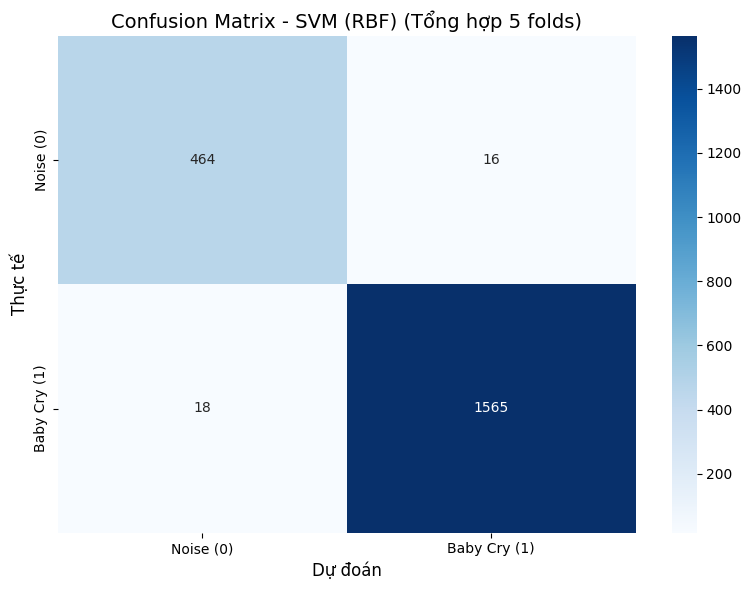


📊 Phân tích:
   - True Negative (Noise → Noise): 464
   - False Positive (Noise → Cry): 16
   - False Negative (Cry → Noise): 18
   - True Positive (Cry → Cry): 1565

📊 Tỉ lệ:
   - Sensitivity/Recall (Cry): 0.9886
   - Specificity (Noise): 0.9667

📈 3.3: ĐƯỜNG CONG ROC - TẤT CẢ MODELS
   Đang train Random Forest...
   Đang train SVM (RBF)...
   Đang train KNN (k=5)...
   Đang train XGBoost...
   Đang train Logistic Regression...


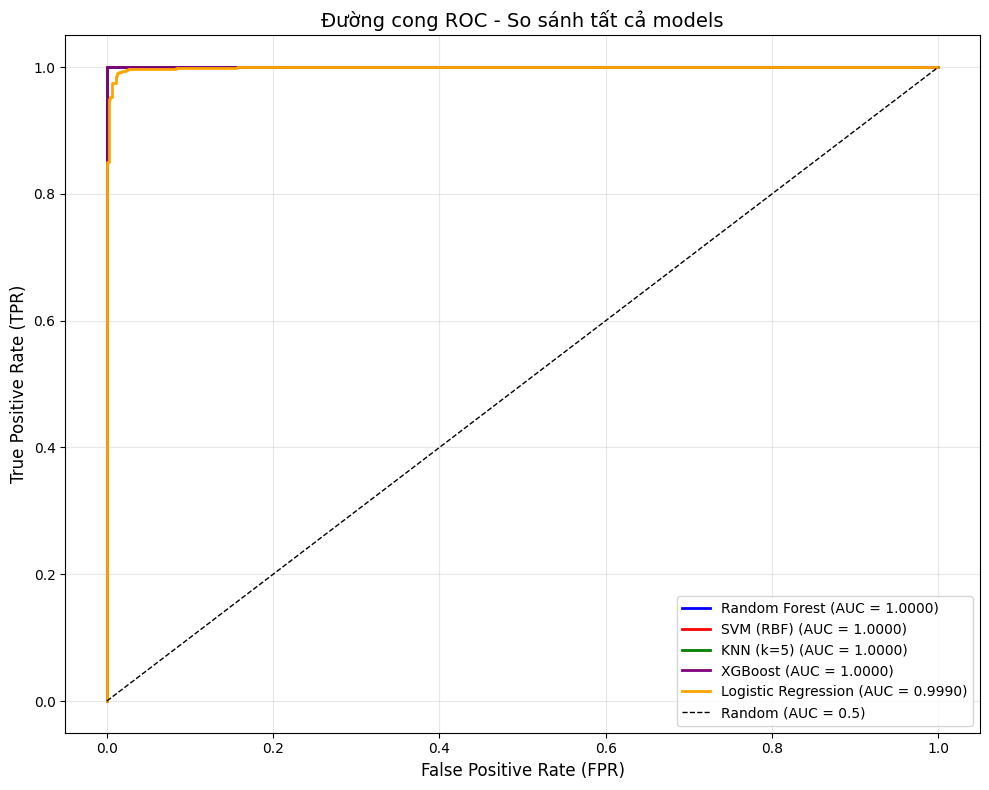


🔍 3.4: FEATURE IMPORTANCE - TOP 15 ĐẶC TRƯNG
⚠️ Model SVM (RBF) không có feature_importances_

🔎 3.5: PHÂN TÍCH LỖI - SO SÁNH CÁC MODELS

📊 Thống kê lỗi tổng hợp (5 folds):
              Model  False_Negative (bỏ sót khóc)  False_Positive (báo động giả)  Total_Errors
          SVM (RBF)                            18                             16            34
      Random Forest                            20                             31            51
            XGBoost                            30                             21            51
Logistic Regression                            42                             19            61
          KNN (k=5)                            15                             52            67

✅ Đã lưu error_analysis_comparison.csv

💾 LƯU KẾT QUẢ
✅ Đã lưu best_model_final.pkl
✅ Đã lưu test_results_full.pkl

✅ HOÀN TẤT BƯỚC 3!


In [5]:
# -*- coding: utf-8 -*-
"""BUOC_3_DANH_GIA_CHI_TIET_ALL_MODELS_ROC.ipynb
Mục tiêu: Đánh giá chi tiết mô hình tốt nhất và so sánh ROC của TẤT CẢ models
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, roc_curve, confusion_matrix, classification_report)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("📊 BƯỚC 3: ĐÁNH GIÁ CHI TIẾT & SO SÁNH ROC TẤT CẢ MODELS")
print("="*70)

# ============================================
# 1. LOAD DỮ LIỆU TỪ BƯỚC 2
# ============================================
print("\n📂 Đang load dữ liệu từ Bước 2...")

# Load kết quả cross-validation từ Bước 2
fold_results = joblib.load('fold_results_cv.pkl')      # Kết quả chi tiết từng fold
best_model_data = joblib.load('best_model_cv.pkl')     # Model tốt nhất đã train
fold_data = joblib.load('fold_data_cv.pkl')            # Dữ liệu fold từ Bước 1

best_model_name = best_model_data['best_model_name']
best_model = best_model_data['best_model']
feature_names = best_model_data['feature_names']
train_info = best_model_data['train_info']

print(f"✅ Mô hình tốt nhất từ cross-validation: {best_model_name}")
print(f"✅ Đã huấn luyện trên {train_info['total_samples']} mẫu")
print(f"   - Noise: {train_info['noise_samples']}")
print(f"   - Baby Cry: {train_info['baby_samples']}")

# ============================================
# 2. BẢNG SO SÁNH CÁC MODELS TỪ CROSS-VALIDATION
# ============================================
print("\n" + "="*70)
print("📊 3.1: BẢNG SO SÁNH CÁC MODELS (5-FOLD CV)")
print("="*70)

# Tổng hợp kết quả từ fold_results
metrics_summary = {}

for model_name in fold_results.keys():
    acc_list = []
    prec_list = []
    rec_list = []
    f1_list = []
    auc_list = []
    
    for fold in range(1, 6):
        metrics = fold_results[model_name][fold]
        acc_list.append(metrics['accuracy'])
        prec_list.append(metrics['precision'])
        rec_list.append(metrics['recall'])
        f1_list.append(metrics['f1'])
        auc_list.append(metrics['auc'])
    
    metrics_summary[model_name] = {
        'accuracy': f"{np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}",
        'precision': f"{np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}",
        'recall': f"{np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}",
        'f1': f"{np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}",
        'auc': f"{np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}"
    }

metrics_df = pd.DataFrame(metrics_summary).T
metrics_df = metrics_df.sort_values('f1', ascending=False)
print("\n", metrics_df)

# Lưu bảng so sánh
metrics_df.to_csv('models_comparison_cv.csv')
print("\n✅ Đã lưu models_comparison_cv.csv")

# ============================================
# 3. CONFUSION MATRIX CHO MODEL TỐT NHẤT (TỔNG HỢP TỪ CÁC FOLD)
# ============================================
print("\n" + "="*70)
print("📊 3.2: CONFUSION MATRIX - MODEL TỐT NHẤT")
print("="*70)

# Tổng hợp confusion matrix từ tất cả các fold
total_cm = np.zeros((2, 2), dtype=int)

for fold in range(1, 6):
    cm = np.array(fold_results[best_model_name][fold]['confusion_matrix'])
    total_cm += cm

print(f"\n📊 Confusion Matrix tổng hợp (từ 5 folds):")
print(f"   TN: {total_cm[0,0]}, FP: {total_cm[0,1]}")
print(f"   FN: {total_cm[1,0]}, TP: {total_cm[1,1]}")

# Vẽ confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Noise (0)', 'Baby Cry (1)'],
            yticklabels=['Noise (0)', 'Baby Cry (1)'])
plt.xlabel('Dự đoán', fontsize=12)
plt.ylabel('Thực tế', fontsize=12)
plt.title(f'Confusion Matrix - {best_model_name} (Tổng hợp 5 folds)', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Phân tích
tn, fp, fn, tp = total_cm.ravel()
print(f"\n📊 Phân tích:")
print(f"   - True Negative (Noise → Noise): {tn}")
print(f"   - False Positive (Noise → Cry): {fp}")
print(f"   - False Negative (Cry → Noise): {fn}")
print(f"   - True Positive (Cry → Cry): {tp}")
print(f"\n📊 Tỉ lệ:")
print(f"   - Sensitivity/Recall (Cry): {tp/(tp+fn):.4f}")
print(f"   - Specificity (Noise): {tn/(tn+fp):.4f}")

# ============================================
# 4. ĐƯỜNG CONG ROC CHO TẤT CẢ MODELS (TỔNG HỢP TỪ CÁC FOLD)
# ============================================
print("\n" + "="*70)
print("📈 3.3: ĐƯỜNG CONG ROC - TẤT CẢ MODELS")
print("="*70)

plt.figure(figsize=(10, 8))
colors = {'Random Forest': 'blue', 'SVM (RBF)': 'red', 'KNN (k=5)': 'green', 
          'XGBoost': 'purple', 'Logistic Regression': 'orange'}

# Lấy tất cả test data từ các fold
X_test_all = []
y_test_all = []

for fold in range(1, 6):
    X_test_all.append(fold_data[fold]['X_test_scaled'])
    y_test_all.append(fold_data[fold]['y_test'])

X_test_combined = np.vstack(X_test_all)
y_test_combined = np.hstack(y_test_all)

# Lấy tất cả train data từ các fold
X_train_all = []
y_train_all = []

for fold in range(1, 6):
    X_train_all.append(fold_data[fold]['X_train_scaled'])
    y_train_all.append(fold_data[fold]['y_train'])

X_train_combined = np.vstack(X_train_all)
y_train_combined = np.hstack(y_train_all)

# Định nghĩa lại các model
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42, class_weight='balanced'),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", use_label_encoder=False,
                              scale_pos_weight=np.sum(y_train_combined == 0) / np.sum(y_train_combined == 1)),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
}

# Train và vẽ ROC cho từng model
for name, model in models.items():
    print(f"   Đang train {name}...")
    model.fit(X_train_combined, y_train_combined)
    y_prob = model.predict_proba(X_test_combined)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_combined, y_prob)
    auc = roc_auc_score(y_test_combined, y_prob)
    
    plt.plot(fpr, tpr, color=colors[name], linewidth=2, 
             label=f'{name} (AUC = {auc:.4f})')

# Đường chéo random
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Đường cong ROC - So sánh tất cả models', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 5. FEATURE IMPORTANCE (NẾU CÓ)
# ============================================
print("\n" + "="*70)
print("🔍 3.4: FEATURE IMPORTANCE - TOP 15 ĐẶC TRƯNG")
print("="*70)

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    
    feat_imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    top15 = feat_imp_df.head(15)
    
    print(f"\n📊 TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT ({best_model_name}):")
    for idx, row in top15.iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top15)), top15['importance'].values, color='steelblue')
    plt.yticks(range(len(top15)), top15['feature'].values)
    plt.xlabel('Mức độ quan trọng', fontsize=12)
    plt.title(f'Top 15 đặc trưng quan trọng nhất - {best_model_name}', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance_top15.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    top15.to_csv('feature_importance_top15.csv', index=False)
    print("✅ Đã lưu feature_importance_top15.csv")
else:
    print(f"⚠️ Model {best_model_name} không có feature_importances_")

# ============================================
# 6. PHÂN TÍCH LỖI - SO SÁNH CÁC MODELS
# ============================================
print("\n" + "="*70)
print("🔎 3.5: PHÂN TÍCH LỖI - SO SÁNH CÁC MODELS")
print("="*70)

error_stats = []
for model_name in fold_results.keys():
    total_fn = 0
    total_fp = 0
    
    for fold in range(1, 6):
        cm = np.array(fold_results[model_name][fold]['confusion_matrix'])
        tn, fp, fn, tp = cm.ravel()
        total_fn += fn
        total_fp += fp
    
    error_stats.append({
        'Model': model_name,
        'False_Negative (bỏ sót khóc)': total_fn,
        'False_Positive (báo động giả)': total_fp,
        'Total_Errors': total_fn + total_fp
    })

error_df = pd.DataFrame(error_stats).sort_values('Total_Errors')
print("\n📊 Thống kê lỗi tổng hợp (5 folds):")
print(error_df.to_string(index=False))

error_df.to_csv('error_analysis_comparison.csv', index=False)
print("\n✅ Đã lưu error_analysis_comparison.csv")

# ============================================
# 7. LƯU KẾT QUẢ
# ============================================
print("\n" + "="*70)
print("💾 LƯU KẾT QUẢ")
print("="*70)

joblib.dump(best_model, 'best_model_final.pkl')
print("✅ Đã lưu best_model_final.pkl")

test_results_full = {
    'best_model_name': best_model_name,
    'cv_metrics': metrics_df.to_dict(),
    'total_confusion_matrix': total_cm.tolist(),
    'error_analysis': error_stats
}
joblib.dump(test_results_full, 'test_results_full.pkl')
print("✅ Đã lưu test_results_full.pkl")

print("\n" + "="*70)
print("✅ HOÀN TẤT BƯỚC 3!")
print("="*70)